In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

df = pd.read_excel('MALLM_plot.xlsx')

vars_ = ['Model', 'Reference', 'MA/SR Info', 'Section screened']
labels = [v.replace('Section screened', 'Section \nscreened') for v in vars_]

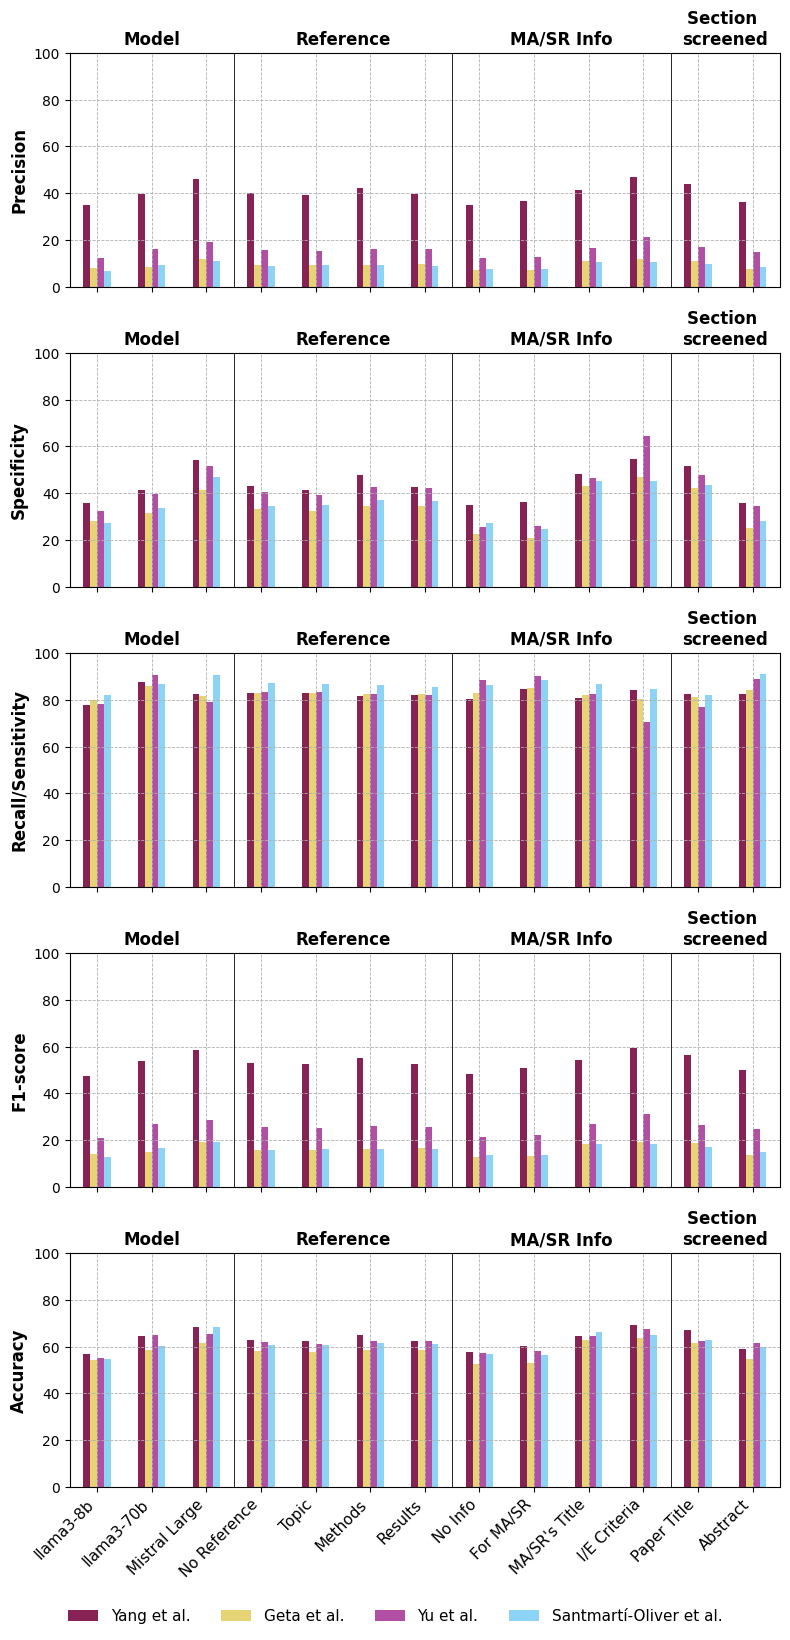

In [74]:
ma_order = ["Yang et al.", "Geta et al.", "Yu et al.", "Santmartí-Oliver et al."]
colors = {
    "Yang et al.": "#872254",
    "Geta et al.": "#E6D374",
    "Yu et al.": "#B14FA4",
    "Santmartí-Oliver et al.": "#8CD3F5"
}

metrics = ["Precision", "Specificity", "Recall/Sensitivity", "F1-score", "Accuracy"]

def build_pt(metric_col):
    blocks, sizes = [], []
    for v in vars_:
        if v == 'Model':
            order = ['llama3-8b', 'llama3-70b', 'Mistral Large']
        else:
            order = df[v].astype(str).dropna().unique()
        p = df.groupby([v, 'MA'])[metric_col].mean().unstack('MA').reindex(order)
        p.index = pd.MultiIndex.from_product([[v], p.index], names=['var', 'level'])
        blocks.append(p)
        sizes.append(len(p))
    pt = pd.concat(blocks)
    pt = pt.reindex(columns=ma_order)  # fixed MA order
    return pt, sizes

fig, axes = plt.subplots(nrows=len(metrics), ncols=1, figsize=(8, 16), sharex=True, sharey=True)

for ax, metric in zip(axes, metrics):
    pt, sizes = build_pt(metric)
    pt.droplevel('var').plot(kind='bar', ax=ax,
                             color=[colors[c] for c in ma_order], legend=False)
    ax.set_ylabel(metric, fontweight='bold', fontsize=12)
    ax.grid(True, which='both', axis='both', linestyle='--', linewidth=0.6)
    ax.set_ylim(0, 100)
    ax.set_xlabel('')

    # vertical separators
    cuts = np.cumsum(sizes)[:-1]
    for c in cuts:
        ax.axvline(c - 0.5, color='k', linewidth=0.6)

    # category labels above sections
    ymax = ax.get_ylim()[1]
    start = 0
    for v, label, size in zip(vars_, labels, sizes):
        mid = start + size / 2 - 0.5
        ax.text(mid, ymax * 1.02, label, ha='center', va='bottom', fontsize=12, fontweight='bold')
        start += size

# common legend
handles, _ = axes[0].get_legend_handles_labels()

plt.subplots_adjust(bottom=0.14) 

# custom legend with correct color↔label mapping
legend_handles = [Patch(facecolor=colors[m], label=m) for m in ma_order]
fig.legend(
    handles=legend_handles,
    title='',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.00005),  # moves it below the plot
    ncol=4,
    frameon=False,
    fontsize=11,
    title_fontsize=11
)

plt.xticks(fontsize=11, rotation=45, ha='right')
plt.tight_layout()
fig.savefig('MALLM_metrics.jpg', dpi=300, bbox_inches='tight')  # save
plt.show()  # then display